# Problem Statement
Using the relevant machine learning model implement the given data

In [1]:
#load all the libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#load the data
data = pd.read_csv('diabetes.csv')

In [3]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Domain analsyis

Take the linear regression file as a reference and write the domian analysis for this data

# Basic checks

In [4]:
data.shape

(768, 9)

 Here the data has 768 rows and 9 columns

In [5]:
data.head()
#head is showing the first 5 rows of info

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [7]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [8]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [9]:
# since the target value is descrete , analyse the same
data['Outcome'].unique()

array([1, 0])

In [10]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
#by analsying the target column ,we can get to know whether the data is balanced or not
# 0 500 rows info, 1 268 rows of info

# that is more info is there w.r.t to ppl having no diabetes
# less info w,rt to having dia

# if this is the case, we say data is not balanced

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
# Glucose	BloodPressure	SkinThickness	Insulin	BMI
#For these columns the mini value is 0
# it can never go 0 for a person who is alive
# this concludes there are corrupted values in the data
# we should handle them , during cleaing the data, replace 0 by median of the column

# EDA

Univariate analsyis - analyse the single column
              
              - cat / descrete - countplot
              - continuous -> histogram / box
              
Bivarite - 2 col analysis

              - num vs num  -> scatter, line, rel
              - num vs cat   -> count(hue), bar, box (hue)

Multivariate
             
             - Pairplot

In [15]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [17]:
data['Outcome'].unique()

array([1, 0])

In [18]:
data['Pregnancies'].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14])

<Axes: xlabel='Outcome', ylabel='count'>

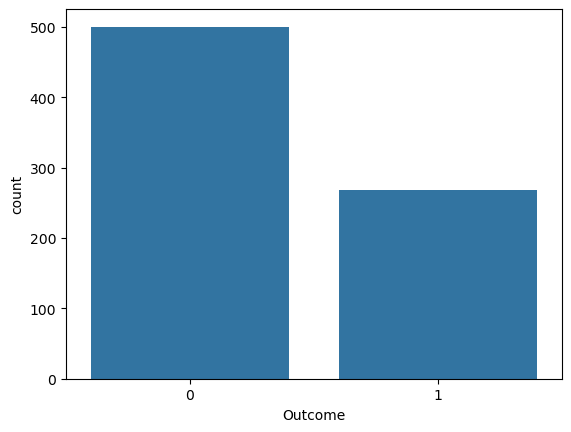

In [19]:
# target column
# count plot
#plt.figure(figsize=(5,3))
sns.countplot(x=data['Outcome'])

Insight: Non diabetic class occurances are more. Data is not balanced

In [20]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
data.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [ ]:
data['Pregnancies'].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14],
      dtype=int64)

<Axes: xlabel='Pregnancies', ylabel='count'>

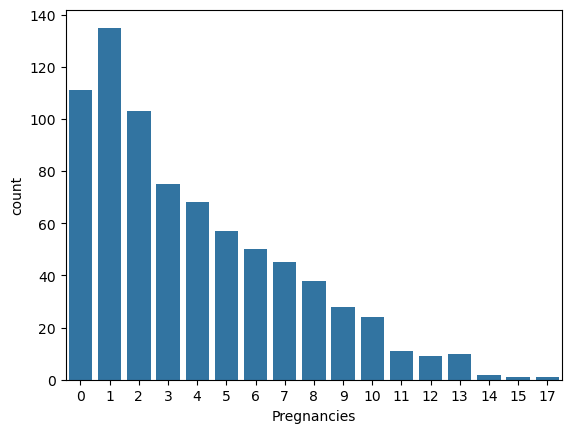

In [20]:
sns.countplot(x=data['Pregnancies'])

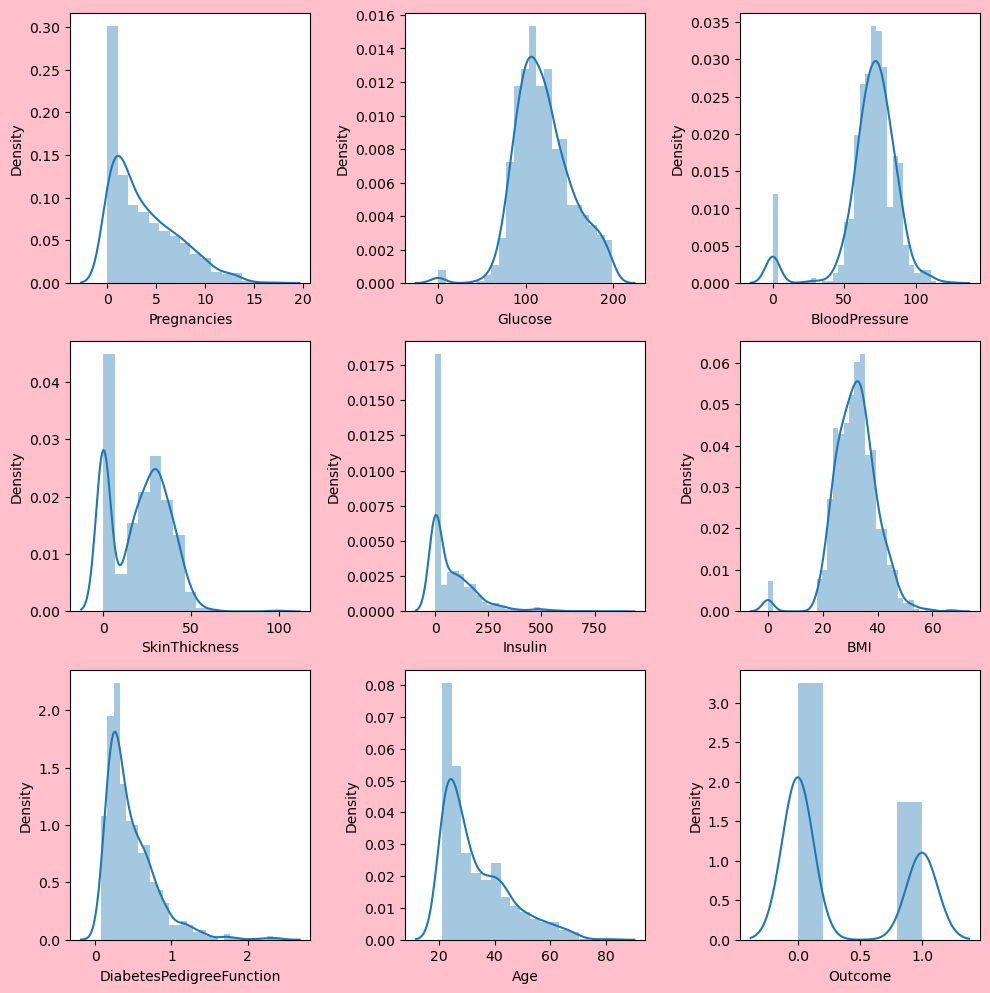

In [14]:
#SUBPLOT
plt.figure(figsize=(10,10),facecolor='pink')
plot = 1

for i in data:
    if plot < 10:
        ax = plt.subplot(3,3,plot)
        sns.distplot(data[i])
        plt.xlabel(i)
    plot+=1
plt.tight_layout()
plt.show()

In [ ]:
#Insights

# Bivariate

<Axes: xlabel='Pregnancies', ylabel='count'>

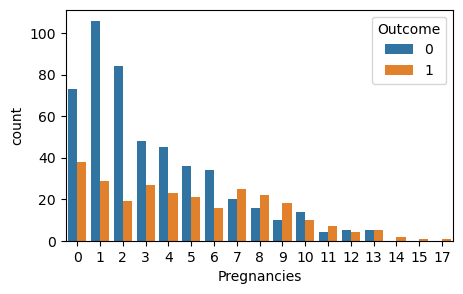

In [42]:
# analyse all the input varibales vs target
plt.figure(figsize=(5,3))
sns.countplot(x=data['Pregnancies'],hue=data['Outcome'])

In [ ]:
#insight : as the number of pregnancies increases the chances of getting diabetes is also increasing

<Axes: xlabel='Glucose', ylabel='Count'>

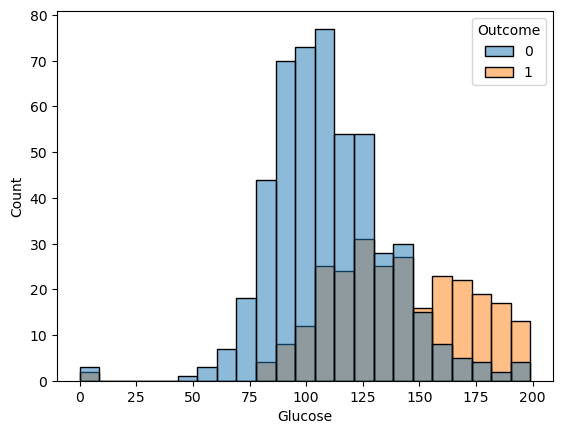

In [21]:
sns.histplot(x=data['Glucose'],hue=data['Outcome'])

In [ ]:
#insight :

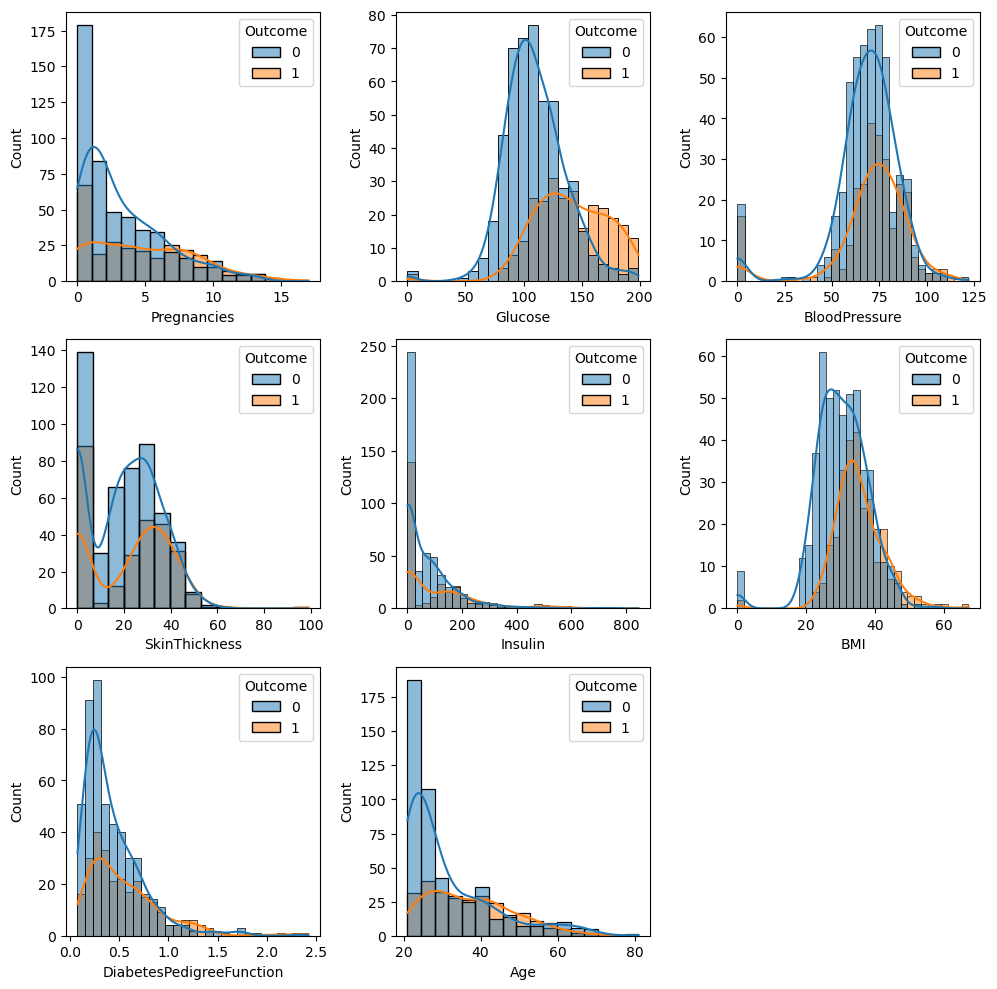

In [71]:
#SUBPLOT - input vs target
plt.figure(figsize=(10,10))
plotnumber = 1

for i in data.drop('Outcome',axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.histplot(x=data[i], hue=data['Outcome'],kde=True)
        plt.xlabel(i,fontsize=10)
    plotnumber +=1
plt.tight_layout()



In [ ]:
#insight for all the graphs

# Pair plot

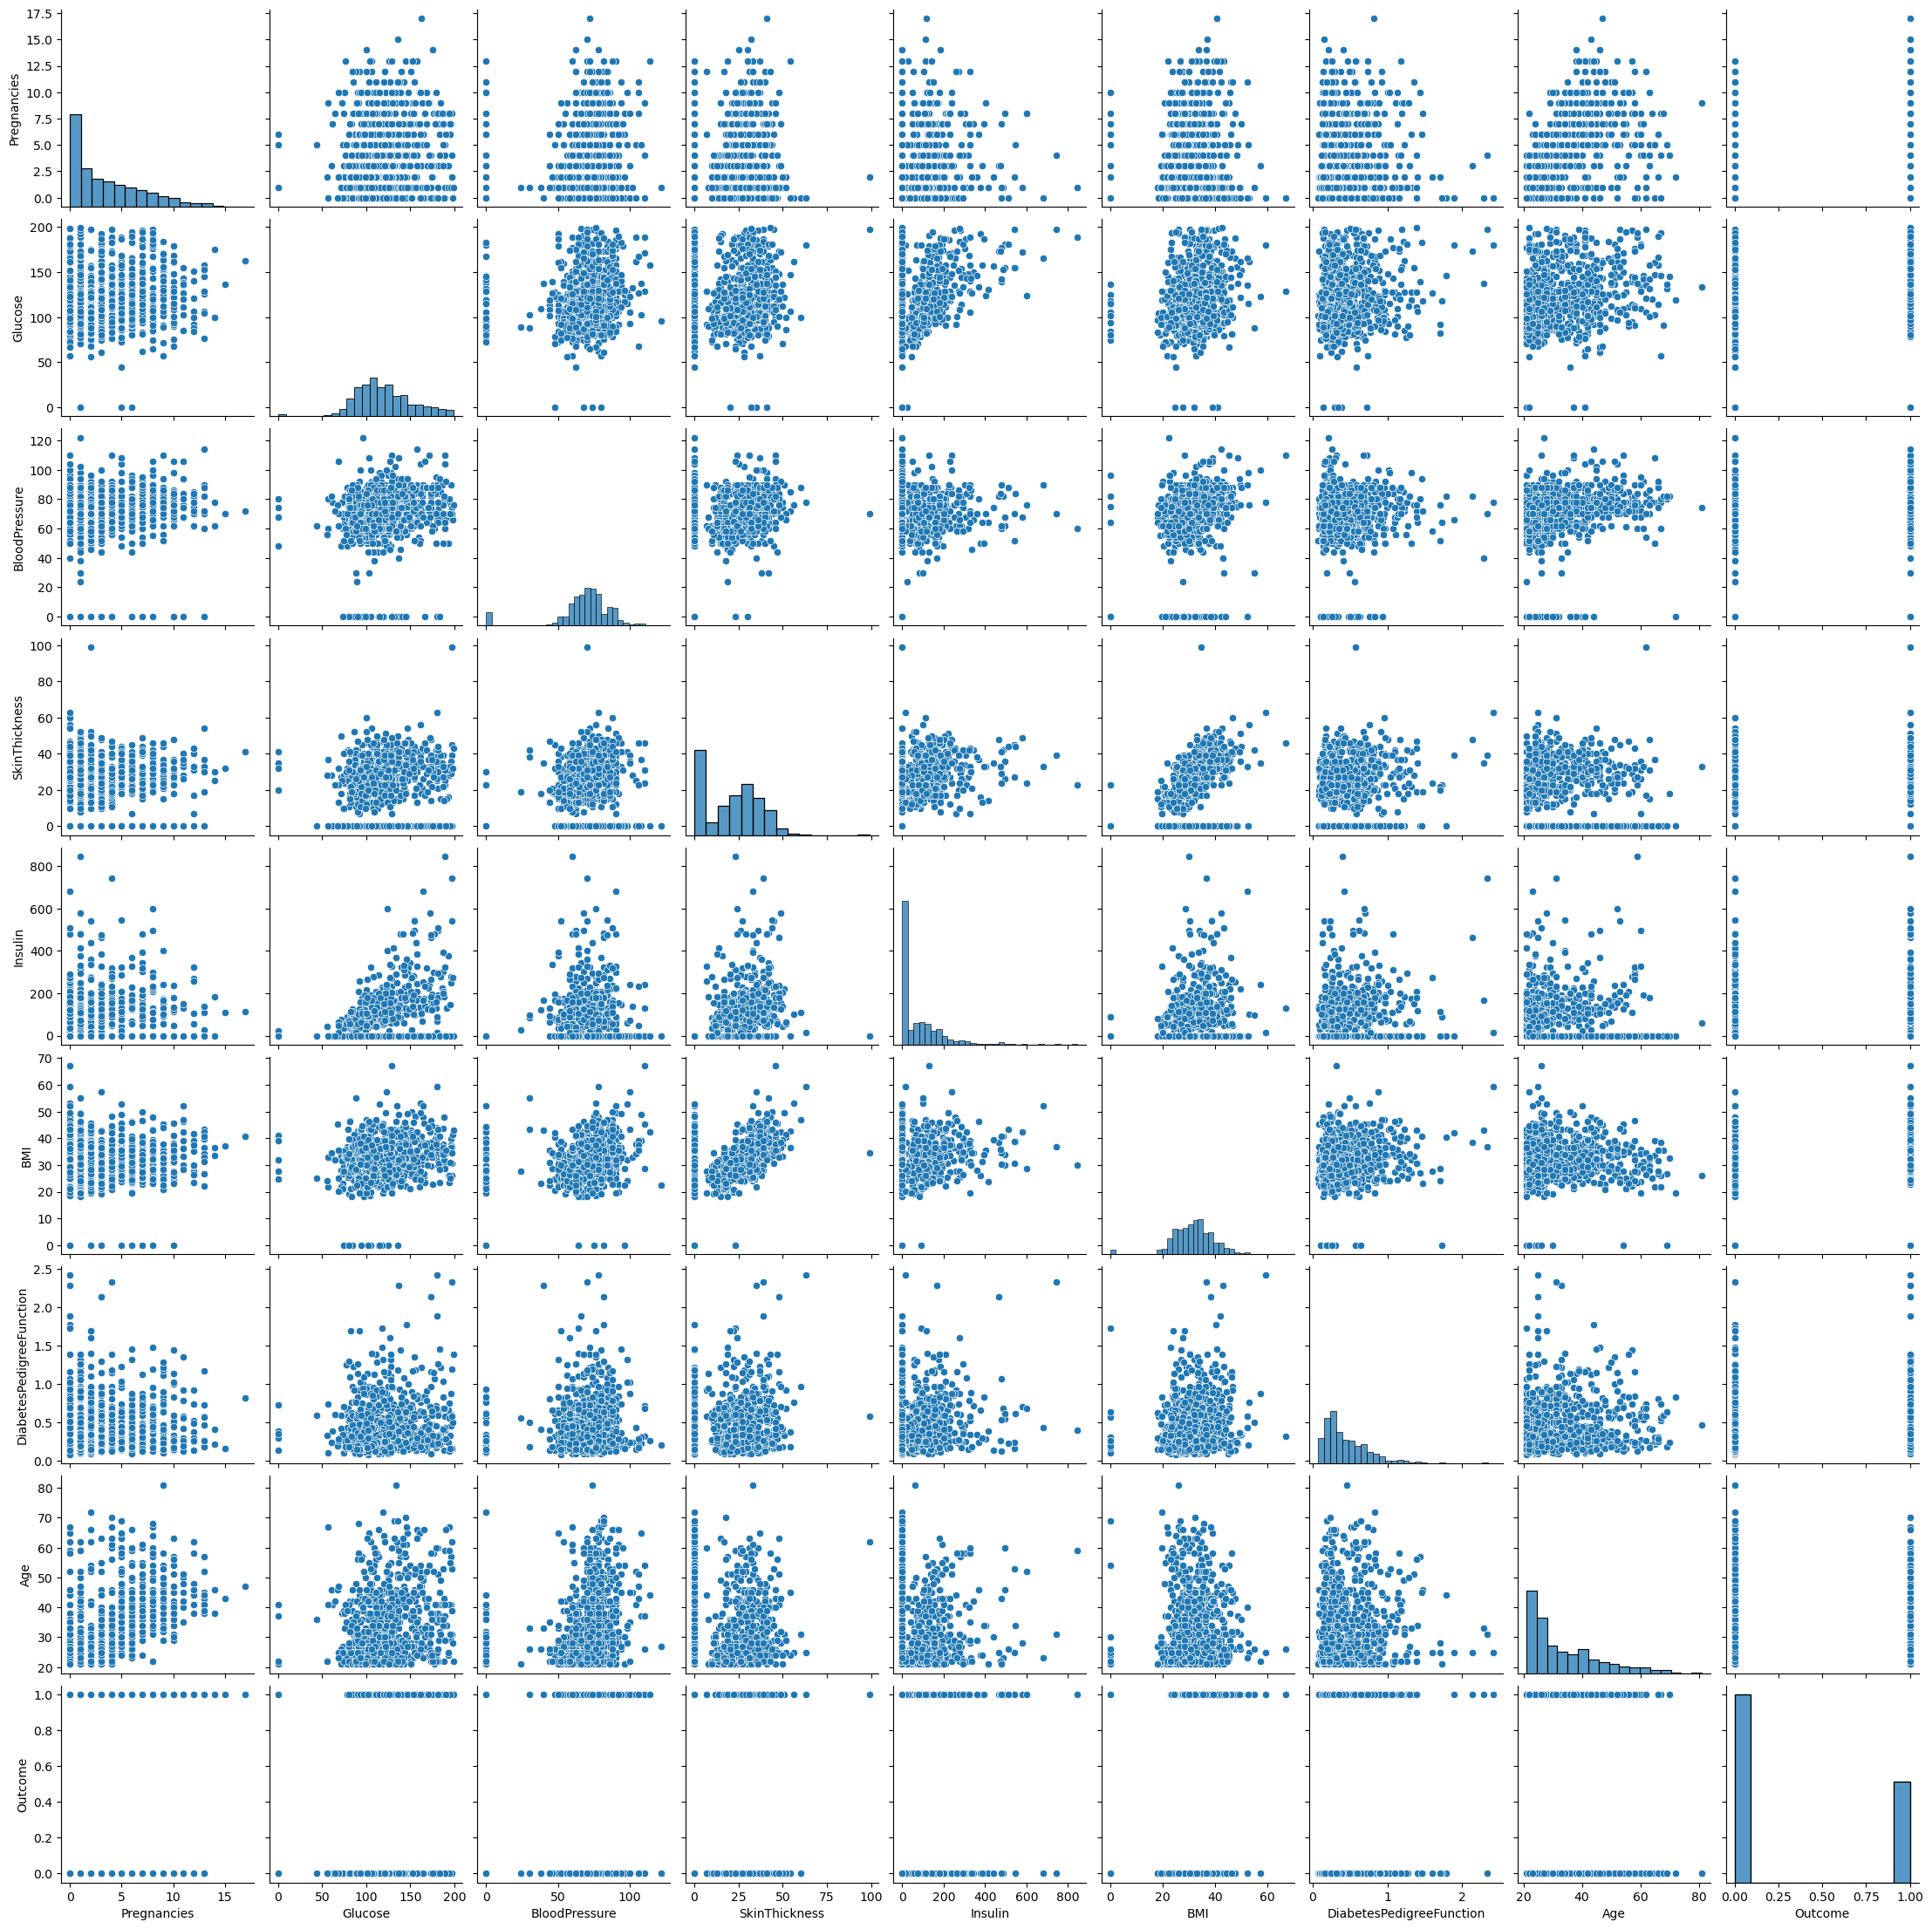

In [43]:
#sns.pairplot(data)
sns.pairplot(data)

# Pre processing

In [44]:
#null values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [45]:
data.duplicated().sum()

0

In [ ]:
# Glucose	BloodPressure	SkinThickness	Insulin	BMI
#For these columns the mini value is 0
# it can never go 0 for a person who is alive
# this concludes there are corrupted values in the data
# we should handle them , during cleaing the data, replace 0 by median of the column

In [15]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [22]:
data.loc[data['Glucose']==0,'Glucose'] = data['Glucose'].median()

In [23]:
data['BloodPressure'].replace(0,data['BloodPressure'].median(),inplace=True)

In [24]:
data['SkinThickness'].replace(0, data['SkinThickness'].median(),inplace = True)
data['Insulin'].replace(0, data['Insulin'].median(),inplace = True)
data['BMI'].replace(0, data['BMI'].median(),inplace = True)

In [25]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [26]:
#outlier detection
#handling outlier is very important for the logistic model
# plot a box plot and then decide whether a column has a outlier or not


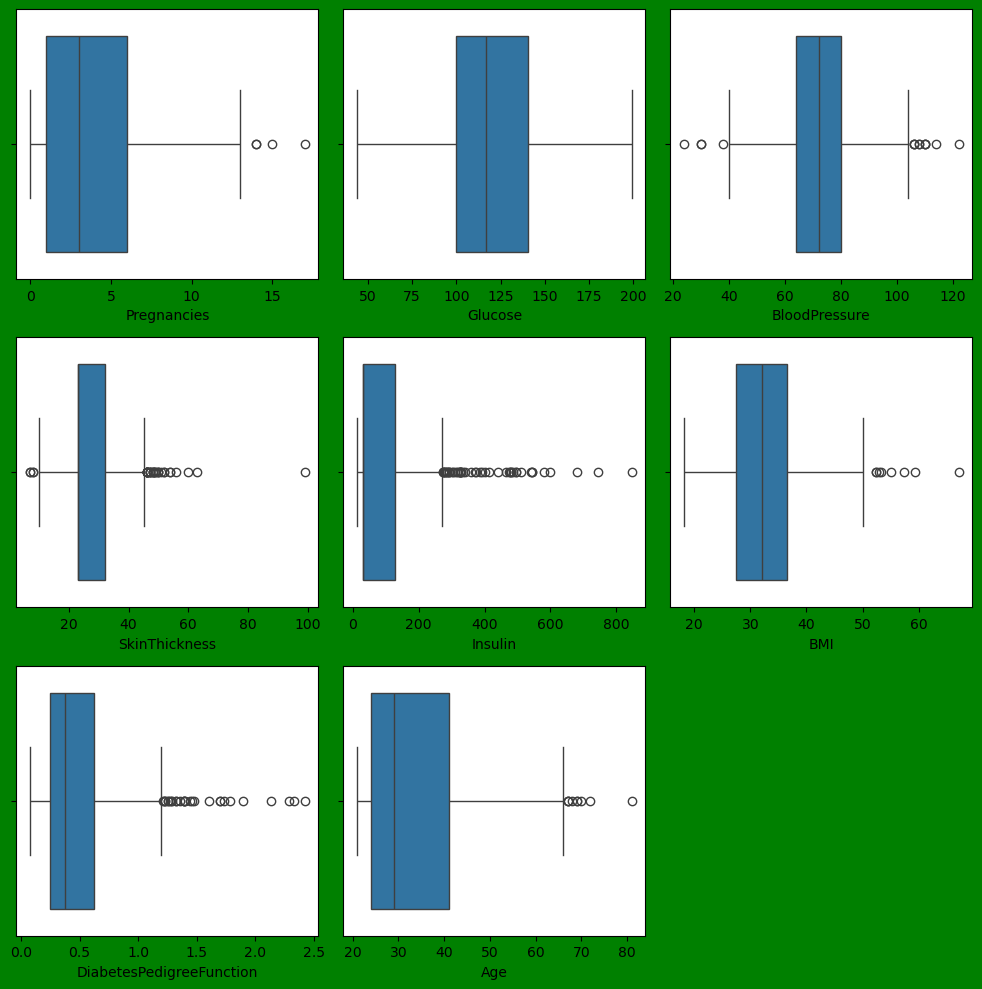

In [27]:
#SUBPLOT
plt.figure(figsize=(10,10),facecolor="green")
plotnumber = 1

for i in data.drop('Outcome',axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.boxplot(x=data[i])
        plt.xlabel(i,fontsize=10)
    plotnumber +=1
plt.tight_layout()



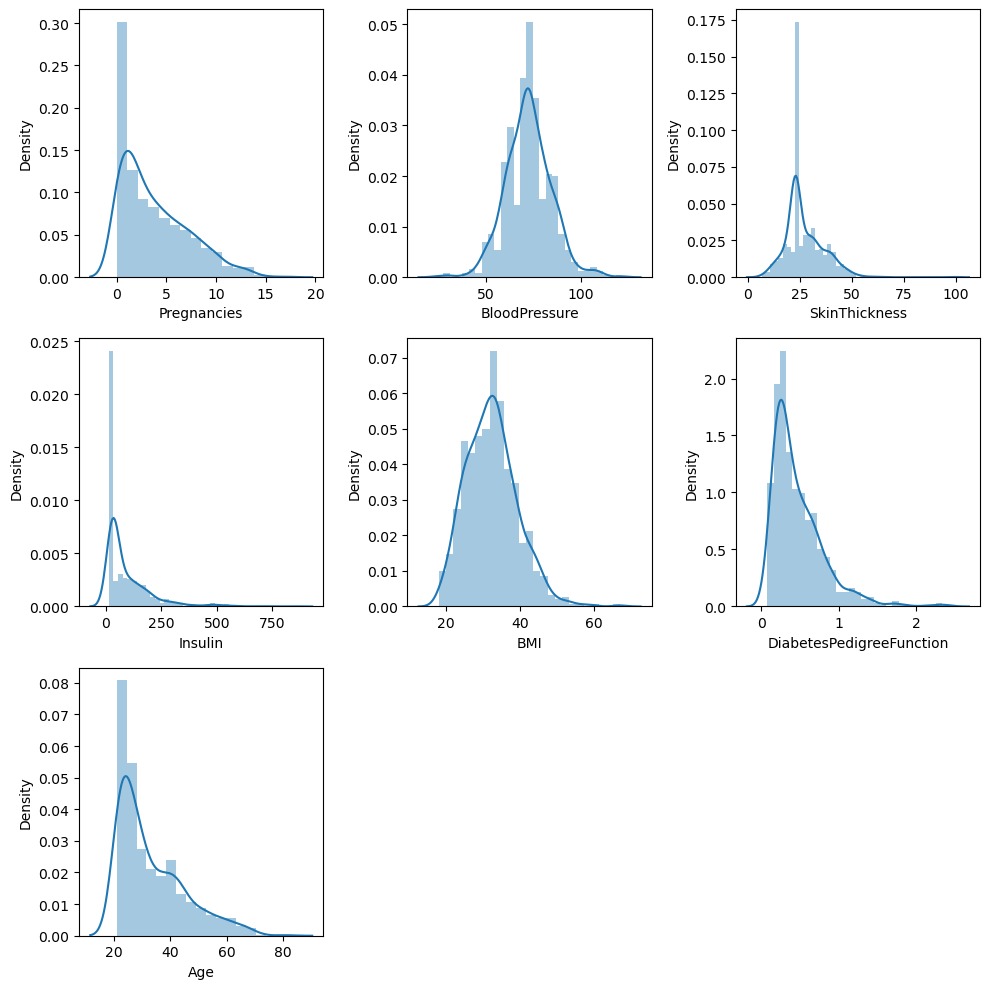

In [57]:
# we can see all the column has outliers
# we need to handle them
# for us to handle , we need to get to know the distribution
#SUBPLOT
plt.figure(figsize=(10,10))
plotnumber = 1

for i in data.drop(columns=['Glucose','Outcome'],axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.distplot(x=data[i])
        plt.xlabel(i,fontsize=10)
    plotnumber +=1
plt.tight_layout()



In [ ]:
# all the above columns are giving us the skewed distribution, hence we are handling outliers by
# IQR method
# task

# Feature selection

In [ ]:
#drop the irrlevant columns

<Axes: >

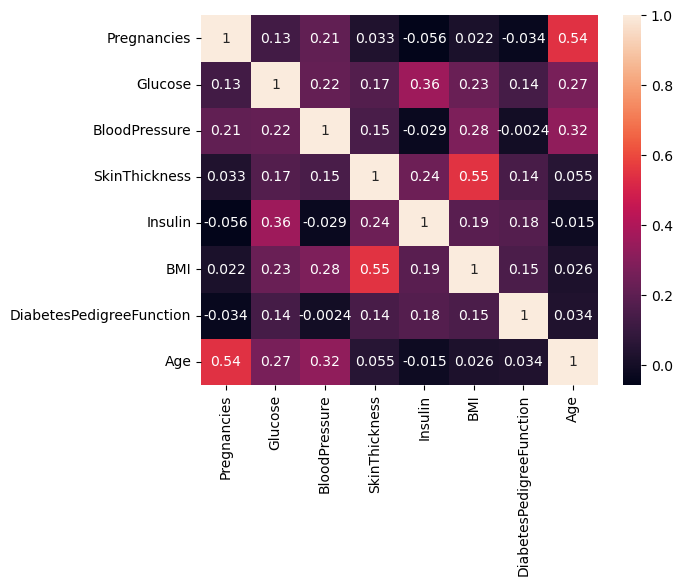

In [28]:
# co relation of data
sns.heatmap(data.drop('Outcome',axis=1).corr(),annot=True)

In [ ]:
# no two input columns show corelation higher 80% so we are selecting all the columns

# Model Building

In [29]:
x = data.drop('Outcome',axis=1)
y = data[['Outcome']]

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train , y_test = train_test_split(x,y,test_size=0.30,random_state=4)

In [31]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = pd.DataFrame(sc.fit_transform(x_train),columns=x_train.columns)#Fit_transform only for training
x_test = pd.DataFrame(sc.transform(x_test),columns=x_test.columns)

In [32]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.059533,-0.895293,-0.162504,0.506497,-0.650832,-0.051119,0.397562,-0.773077
1,-1.135569,-0.077711,0.003241,-0.466049,-0.650832,-0.007957,-1.009913,-0.773077
2,-0.538018,-0.724964,-0.162504,2.667709,-0.386477,1.157407,0.591800,-0.687144
3,1.553409,1.046465,0.500477,0.722618,0.750746,0.251013,1.237266,0.000320
4,-1.135569,0.262948,3.152400,2.019345,0.341745,4.984405,-0.478001,-0.601211
...,...,...,...,...,...,...,...,...
532,0.358308,2.306904,-0.659740,0.614557,2.286995,-0.180604,0.310903,-0.343412
533,-0.538018,-0.963425,-0.659740,0.506497,0.641014,0.797727,0.582835,-0.859010
534,0.657083,-0.486502,1.329203,-0.466049,-0.650832,0.625080,0.741213,-0.171546
535,-0.538018,-1.576612,-0.659740,-0.357989,-0.406429,-0.396412,-0.325599,0.000320


In [33]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.836794,-0.724964,-0.493995,0.182315,1.000137,-0.065506,-0.104467,0.773718
1,1.553409,-2.189799,0.666222,1.046800,-0.650832,0.049592,-1.144385,0.687784
2,-1.135569,-0.724964,-0.162504,-0.141867,-0.456307,-0.238153,0.352738,-1.030877
3,-0.836794,-0.077711,1.329203,1.479042,0.740770,1.847993,0.083794,-0.601211
4,-0.538018,-0.656832,1.163457,0.938739,0.241988,1.876768,-1.051749,-0.859010
...,...,...,...,...,...,...,...,...
226,-1.135569,1.966245,-1.819957,0.938739,0.631038,0.768952,-0.071596,-0.944944
227,0.358308,-0.418370,-0.825485,1.479042,0.331769,0.481208,0.104712,-0.687144
228,-0.239243,0.297014,0.500477,-0.466049,-0.167013,-0.583446,-0.466048,0.086253
229,-1.135569,-0.895293,-0.659740,1.262921,0.092354,1.747283,-0.337552,-0.944944


In [34]:
#apply the logistic Regression
#import the algo
from sklearn.linear_model import LogisticRegression

# init
model = LogisticRegression()

# train the model
model.fit(x_train, y_train)

LogisticRegression()

In [35]:
# test the model with new records
# x_test
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0])

# Evaluate the model


In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score,classification_report


In [37]:
confusion_matrix(y_test,y_pred)

array([[136,  16],
       [ 27,  52]])

In [38]:
accuracy_score(y_test,y_pred)

0.8138528138528138

In [39]:
precision_score(y_test,y_pred)

0.7647058823529411

In [40]:
f1_score(y_test,y_pred)

0.7074829931972789

In [41]:
recall_score(y_test,y_pred)

0.6582278481012658

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       152
           1       0.76      0.66      0.71        79

    accuracy                           0.81       231
   macro avg       0.80      0.78      0.79       231
weighted avg       0.81      0.81      0.81       231



In [43]:
from sklearn.metrics import roc_curve, auc
false_positive_rate, true_positive_rate , thresholds = roc_curve(y_test,y_pred)
auc_score = auc(false_positive_rate, true_positive_rate)
auc_score

np.float64(0.7764823451032645)

In [44]:
thresholds #infinity,1 0

array([inf,  1.,  0.])

In [122]:
false_positive_rate

array([0.        , 0.10526316, 1.        ])

In [123]:
true_positive_rate

array([0.        , 0.65822785, 1.        ])

In [ ]:
# model performance is good